In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/monthly_births_2024.csv")

print(df)
print("\nShape:", df.shape)

    month  births month_name
0       1  297798    January
1       2  283858   February
2       3  298760      March
3       4  290212      April
4       5  303925        May
5       6  293893       June
6       7  319953       July
7       8  326595     August
8       9  309136  September
9      10  314890    October
10     11  292568   November
11     12  306848   December

Shape: (12, 3)


In [2]:
df["month"] = df["month"].astype(str).str.zfill(2)

df["ds"] = pd.to_datetime(
    "2024-" + df["month"] + "-01"
)

df["y"] = df["births"]

forecast_df = df[["ds", "y"]].copy()

print(forecast_df)

           ds       y
0  2024-01-01  297798
1  2024-02-01  283858
2  2024-03-01  298760
3  2024-04-01  290212
4  2024-05-01  303925
5  2024-06-01  293893
6  2024-07-01  319953
7  2024-08-01  326595
8  2024-09-01  309136
9  2024-10-01  314890
10 2024-11-01  292568
11 2024-12-01  306848


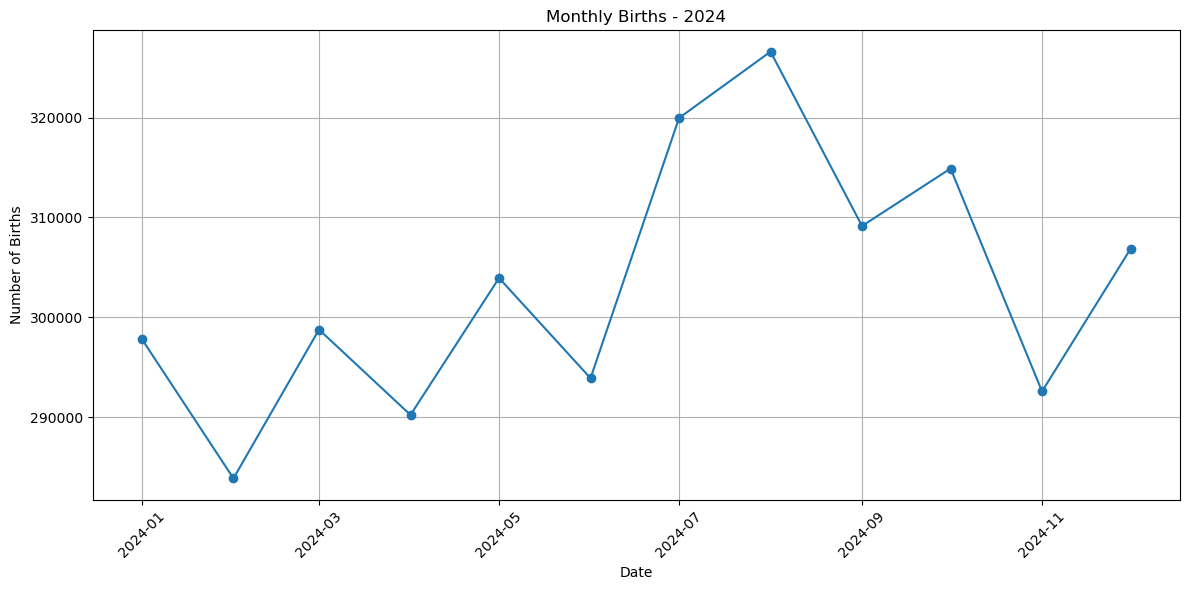

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    forecast_df["ds"],
    forecast_df["y"],
    marker="o"
)

plt.title("Monthly Births - 2024")
plt.xlabel("Date")
plt.ylabel("Number of Births")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
%pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [5]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(forecast_df)

print("Prophet model trained successfully!")

17:32:19 - cmdstanpy - INFO - Chain [1] start processing
17:32:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!


In [6]:
future = model.make_future_dataframe(
    periods=6,
    freq="MS"
)

print(future.tail(6))

           ds
12 2025-01-01
13 2025-02-01
14 2025-03-01
15 2025-04-01
16 2025-05-01
17 2025-06-01


In [7]:
forecast = model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(6)

,ds,yhat,yhat_lower,yhat_upper
12,2025-01-01,314064.925294,300230.963977,328274.274630
13,2025-02-01,315755.902652,301637.869385,329040.115073
14,2025-03-01,317283.237040,302812.490900,331023.392645
15,2025-04-01,318974.214398,304848.460721,332780.748061
16,2025-05-01,320610.644100,306622.840696,333809.430017
17,2025-06-01,322301.621458,308469.899446,335906.611174


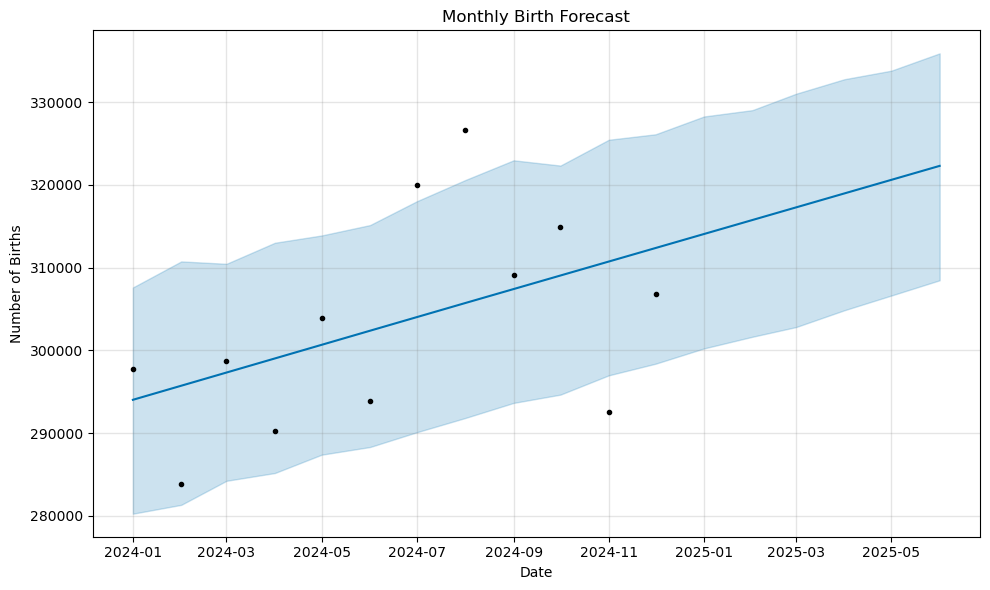

In [8]:
import matplotlib.pyplot as plt

fig = model.plot(forecast)

plt.title("Monthly Birth Forecast")
plt.xlabel("Date")
plt.ylabel("Number of Births")

plt.tight_layout()
plt.show()

In [9]:
forecast_output = forecast[[
    "ds",
    "yhat",
    "yhat_lower",
    "yhat_upper"
]].copy()

forecast_output.to_csv(
    "data/birth_forecast.csv",
    index=False
)

print("Forecast saved successfully!")

Forecast saved successfully!


In [10]:
import pandas as pd

saved_forecast = pd.read_csv("data/birth_forecast.csv")

print(saved_forecast.head())
print("\nShape:", saved_forecast.shape)
print("\nColumns:", saved_forecast.columns.tolist())

           ds           yhat     yhat_lower     yhat_upper
0  2024-01-01  294018.050152  280248.491000  307600.149647
1  2024-02-01  295722.018665  281316.920703  310751.012247
2  2024-03-01  297316.053734  284226.340166  310461.190449
3  2024-04-01  299020.022178  285165.872021  313006.977002
4  2024-05-01  300669.023818  287383.130170  313888.961196

Shape: (18, 4)

Columns: ['ds', 'yhat', 'yhat_lower', 'yhat_upper']


In [11]:
future_predictions = forecast[
    forecast["ds"] > forecast_df["ds"].max()
][["ds", "yhat", "yhat_lower", "yhat_upper"]]

print(future_predictions)

           ds           yhat     yhat_lower     yhat_upper
12 2025-01-01  314064.925294  300230.963977  328274.274630
13 2025-02-01  315755.902652  301637.869385  329040.115073
14 2025-03-01  317283.237040  302812.490900  331023.392645
15 2025-04-01  318974.214398  304848.460721  332780.748061
16 2025-05-01  320610.644100  306622.840696  333809.430017
17 2025-06-01  322301.621458  308469.899446  335906.611174


In [12]:
forecast_table = future_predictions.copy()

forecast_table["ds"] = pd.to_datetime(forecast_table["ds"])
forecast_table["Predicted_Births"] = forecast_table["yhat"].round().astype(int)
forecast_table["Lower_Limit"] = forecast_table["yhat_lower"].round().astype(int)
forecast_table["Upper_Limit"] = forecast_table["yhat_upper"].round().astype(int)

forecast_table = forecast_table[
    ["ds", "Predicted_Births", "Lower_Limit", "Upper_Limit"]
]

print(forecast_table)

           ds  Predicted_Births  Lower_Limit  Upper_Limit
12 2025-01-01            314065       300231       328274
13 2025-02-01            315756       301638       329040
14 2025-03-01            317283       302812       331023
15 2025-04-01            318974       304848       332781
16 2025-05-01            320611       306623       333809
17 2025-06-01            322302       308470       335907


In [13]:
forecast_table.to_csv(
    "data/final_birth_forecast.csv",
    index=False
)

print("Final forecast table saved successfully!")

Final forecast table saved successfully!
